# K-NN Algorithm

In [2]:
!pip install pandas
!pip install scikit-learn

In [3]:
import cv2
import numpy as np #DataSet Management
import pandas as pd #
import matplotlib.pyplot as plt
from collections import Counter

<h1> Test Data for KNN</h1>

In [4]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score
iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

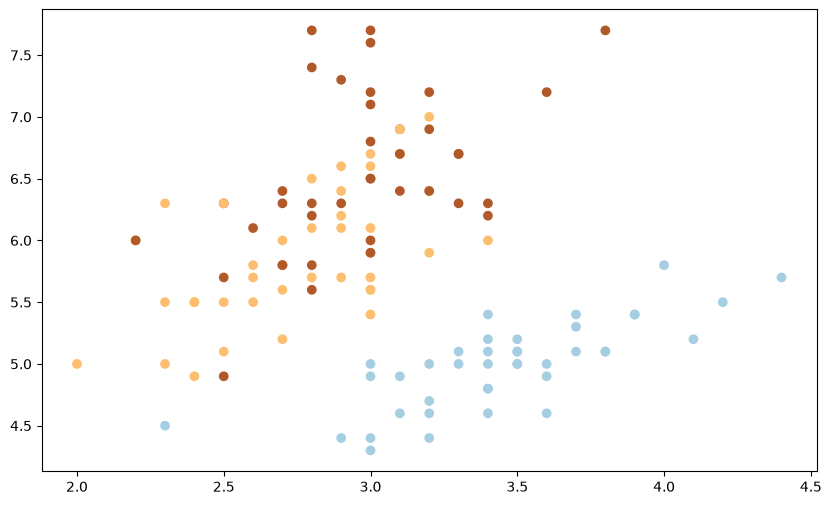

In [5]:
#Showing the iris Graph
plt.figure(figsize=(10, 6))
#X_train are determined based on the (X,Y) coordinates of the Iris Dataset
# Current this is the [0,1] section of the dataset
plt.scatter(X_train[:, 1], X_train[:, 0], c=y_train, cmap=plt.cm.Paired)
plt.show()

<h1> KNN Algorithm (In Development)</h1>

In [9]:
class KNN_Algorithm:
  def __init__(self, k):
    self.k = k

  #Train the KNN Child on the Dataset
  def fit(self, X_train, y_train):
    self.X_train = X_train
    self.y_train = y_train

  #Euclidean Distance Function
  def Euclidean_distance(self, x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))

  #Manhattan Distance Function
  def Manhattan_distance(self, x1, x2):
    return np.sum(np.abs(x1 - x2))

  #Minkowski Distance Function
  def Minkowski_distance(self, x1, x2, p):
    return (np.sum(np.abs(x1- x2)**p))**(1/p)

  #Our Prediction Method
  def predict(self, X_test):
    final_output = []
    for i in range(len(X_test)):
      array = []
      votes = []
      for j in range(len(self.X_train)):
        distance = Euclidean_distance(self.X_train[j], X_test[i])
        array.append([distance, j])
        array.sort()
        array = array[:self.k]
        for d, k in array:
          votes.append(self.y_train[j])
          ans = Counter(votes).most_common(1)[0][0]
          final_output.append(ans)
    return final_output

# Things to be aware of:
    "What is the point of this?" - The algorithm's point is to indetify stars in the sky. Mainly, The algorithm should be able to look at an image, and decipher what objects are and aren't stars. This would involve using Computer Vision, and the use of the openCV library.
    "How can we do this?" - A few points of interest could be breaking down the surrounding negative(black) space around the star to infer that it must be a star. 
    "Why an KNN Algorithm?" - I chose to model the algorithm based on a KNN structure due to feeling like it's ideal for being able to the idea of using its classification 

<h1> Pre-Processing Phase</h1>

In [14]:
def showcase_image(image):
    cv2.imshow("Image", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [16]:
#Turning an Image in a readable 1D Array
'''
1. Load Image & Convert into a Grey Scale version
2. Convert to Matrix and Flatten
3. Normalize Data 

'''
img = cv2.imread("images/pixel image 1.jpg", cv2.IMREAD_GRAYSCALE)
#Resizing image:
img_resized = cv2.resize(img, (32,32))


#Applying a Binary Threshold to emphasis these Dark & Light Spaces

threshold_value = 127
max_value = 255
showcase_image(img)

placeholder, thresh_image = cv2.threshold(img, threshold_value, max_value, cv2.THRESH_BINARY)


img_array = np.array(img_resized)
flatten_image = img_array.reshape(1,-1)

#Normalization
Normalized_data = flatten_image / 255.0
print(Normalized_data)
#plt.imshow(img_resized)

[[0.00392157 0.01176471 0.01176471 ... 0.10980392 0.08235294 0.08235294]]
